# IrriGator — Full End-to-End Pipeline

Central notebook covering **every block** from raw data to irrigation recommendation.

| Block | What | Data source | Run frequency |
|-------|------|-------------|---------------|
| 0 | Data ingestion | ERA5-Land (France-wide), COMEPHORE, Sentinel-2, soil, DEM | Once (historical archive) |
| 1 | Static layers | EU-SoilHydroGrids, IGN DEM | Once per parcel |
| 2 | Atmospheric forcing | ERA5-Land daily → parcel extraction | Once (cache), then per parcel |
| 3+4 | Simulation | Water balance + crop growth ACQUACROP | Daily |
| 5a | Short-term forecast | AROME (0-48h) + IFS ENS (0-15d) → ensemble | Daily |
| 5b | Seasonal outlook | SEAS5 → PCA analog → ensemble water balance | Monthly |
| 6 | Decision | Ensemble stress → irrigation recommendation | Daily |

**Architecture change:** ERA5-Land is now downloaded once for all of metropolitan
France (41°N–51.5°N, 6°W–10°E). Any new parcel is served from this cache
without additional API calls. AROME and IFS ENS already work the same way.

---
## Configuration — set your "today" and paths here

In [ ]:
import logging
import os
from datetime import date
from pathlib import Path

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

TODAY = date(2025, 12, 31)          # the date we treat as "today"
#TODAY = date.today()
SIMULATION_START = date(2025, 1, 1) # start of the growing season simulation
LAST_IRRIGATION = None              # date of last irrigation, or None for rainfed
RUN_SEAS5 = False                   # set True to include seasonal outlook (slow)
SHIFT = 0                           # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")                # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")     # daily aggregates, cached results

# Parcel and region configs (region still needed for static layers)
REGION_CONFIG = "configs/dordogne.yaml"
PARCEL_CONFIG = "configs/parcels/example.yaml"
CROP_PARAMS_PATH = "configs/crop_parameters.yaml"
MODEL_PARAMS_PATH = "configs/model_parameters.yaml"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Repo root: {REPO_ROOT}")
print(f"Today:     {TODAY}")
print(f"Raw dir:   {RAW_DIR}")
print(f"Processed: {PROCESSED_DIR}")

Repo root: /home/mbaldacchino/code/IrriGator
Today:     2025-12-31
Raw dir:   data/raw
Processed: data/processed


---
## Block 0 — Data Ingestion

Run these cells **once** to download and cache the historical archive.
Skip if data is already on disk.

ERA5-Land is downloaded for all of France — not per region. One download
covers any parcel in metropolitan France.

In [2]:
from irrigator.config import load_region_config, load_parcel_config

cfg = load_region_config(REGION_CONFIG)
parcel = load_parcel_config(PARCEL_CONFIG)

print(f"Region: {cfg.name} (dept {cfg.code_departement})")
print(f"Parcel: {parcel.name} ({parcel.id})")
print(f"Crop:   {parcel.crop.get('type')} — planting {parcel.crop.get('planting_date')}")

Region: Dordogne (dept 24)
Parcel: Parcelle Les Graves (24_bergerac_001)
Crop:   grain_maize — planting 2025-04-20


In [20]:
# --- ERA5-Land download (skip if already done) ---
# France-wide, no per-region dependency
from irrigator.ingestion.cds_client import fetch_era5_land_range
fetch_era5_land_range(date(2025, 1, 1), date.today(), raw_dir=RAW_DIR, overwrite=False)

17:17:07 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-01 already exists: data/raw/era5_land/era5land_2025_01.nc
17:17:07 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-02 already exists: data/raw/era5_land/era5land_2025_02.nc
17:17:07 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-03 already exists: data/raw/era5_land/era5land_2025_03.nc
17:17:07 [irrigator.ingestion.cds_client] INFO: Requesting ERA5-Land 2025-04 from CDS...


2026-06-30 17:17:08,015 INFO Request ID is 5529620c-59f1-4c71-9d98-757a7d0ac06b
17:17:08 [ecmwf.datastores.legacy_client] INFO: Request ID is 5529620c-59f1-4c71-9d98-757a7d0ac06b
2026-06-30 17:17:08,079 INFO status has been updated to accepted
17:17:08 [ecmwf.datastores.legacy_client] INFO: status has been updated to accepted
2026-06-30 17:17:29,181 INFO status has been updated to running
17:17:29 [ecmwf.datastores.legacy_client] INFO: status has been updated to running
2026-06-30 17:27:44,404 INFO status has been updated to successful
17:27:44 [ecmwf.datastores.legacy_client] INFO: status has been updated to successful
17:27:46 [multiurl.base] INFO: Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-06-30/d98ca4f3394cac91e48f0205200861c8.nc


d98ca4f3394cac91e48f0205200861c8.nc:   0%|          | 0.00/114M [00:00<?, ?B/s]

17:27:49 [irrigator.ingestion.cds_client] INFO: Downloaded: data/raw/era5_land/era5land_2025_04.nc (119.2 MB)
17:27:49 [irrigator.ingestion.cds_client] INFO: Requesting ERA5-Land 2025-05 from CDS...
2026-06-30 17:27:50,184 INFO Request ID is 83581b26-2f90-46a9-a1bf-dfff7258d821
17:27:50 [ecmwf.datastores.legacy_client] INFO: Request ID is 83581b26-2f90-46a9-a1bf-dfff7258d821
2026-06-30 17:27:50,477 INFO status has been updated to accepted
17:27:50 [ecmwf.datastores.legacy_client] INFO: status has been updated to accepted
2026-06-30 17:28:12,169 INFO status has been updated to running
17:28:12 [ecmwf.datastores.legacy_client] INFO: status has been updated to running
2026-06-30 17:38:31,258 INFO status has been updated to successful
17:38:31 [ecmwf.datastores.legacy_client] INFO: status has been updated to successful
17:38:31 [multiurl.base] INFO: Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-06-30/5d369b7b973622e0d009dcf694efed82.nc


5d369b7b973622e0d009dcf694efed82.nc:   0%|          | 0.00/122M [00:00<?, ?B/s]

...

4778c5575f5a7c4ab8e55c63e4dba7bb.nc:   0%|          | 0.00/113M [00:00<?, ?B/s]

18:50:29 [irrigator.ingestion.cds_client] INFO: Downloaded: data/raw/era5_land/era5land_2025_12.nc (118.5 MB)
18:50:29 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2026-01 already exists: data/raw/era5_land/era5land_2026_01.nc
18:50:29 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2026-02 already exists: data/raw/era5_land/era5land_2026_02.nc
18:50:29 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2026-03 already exists: data/raw/era5_land/era5land_2026_03.nc
18:50:29 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2026-04 already exists: data/raw/era5_land/era5land_2026_04.nc
18:50:29 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2026-05 already exists: data/raw/era5_land/era5land_2026_05.nc
18:50:29 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2026-06 already exists, BUT OVERWRITTEN AS THE MONTH IS NOT FULL: data/raw/era5_land/era5land_2026_06.nc
18:50:29 [irrigator.ingestion.cds_client] INFO: Requesting ERA5-Land 2026-06 from CDS...
2026-06-30 18:50:29,692 INFO Requ

2f3dbc1d7a9e3679d11d3248811f6772.nc:   0%|          | 0.00/91.2M [00:00<?, ?B/s]

18:51:07 [irrigator.ingestion.cds_client] INFO: Downloaded: data/raw/era5_land/era5land_2026_06.nc (95.6 MB)


[PosixPath('data/raw/era5_land/era5land_2025_01.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_02.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_03.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_04.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_05.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_06.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_07.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_08.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_09.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_10.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_11.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_12.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_01.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_02.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_03.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_04.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_05.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_06.nc')]

In [ ]:
# --- Build static layers (skip if already done) ---
# These still use RegionConfig because they depend on the regional DEM/soil grids
# from irrigator.ingestion.esdac_loader import load_soil_hydro, save_soil_hydro
# from irrigator.ingestion.ign_loader import load_terrain, save_terrain
# from irrigator.ingestion.grid import build_grid
#
# grid = build_grid(cfg)
# soil_grid = load_soil_hydro(cfg, grid)
# save_soil_hydro(soil_grid, cfg.processed_dir / "static")
# terrain_grid = load_terrain(cfg, grid)
# save_terrain(terrain_grid, cfg.processed_dir / "static")

---
## Block 1 — Static Layers (parcel-level)

Extract soil and terrain at the parcel location. Run once per parcel, cache.

In [3]:
from irrigator.static_layers.soil import get_soil_profile
from irrigator.static_layers.terrain import get_terrain_params, get_era5_elevation

soil = get_soil_profile(cfg, parcel)
terrain = get_terrain_params(cfg, parcel)
terrain.era5_elevation_m = get_era5_elevation(cfg, parcel)

print(f"Soil AWC:  {soil.total_awc_mm:.0f} mm (source: {soil.source})")
print(f"Elevation: {terrain.elevation_m:.0f} m (ERA5 cell: {terrain.era5_elevation_m:.0f} m)")
print(f"Slope:     {terrain.slope_deg:.1f}°")

21:04:11 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
21:04:11 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.
21:04:14 [irrigator.static_layers.soil] INFO: Parcel 24_bergerac_001: using EU-SoilHydroGrids — AWC=272 mm, FC=[0.340, 0.320, 0.318, 0.310, 0.300, 0.294]
21:04:14 [irrigator.static_layers.terrain] INFO: Parcel 24_bergerac_001 terrain: elev=30 m, slope=2.4°, aspect=185°
21:04:14 [irrigator.ingestion.cds_client] INFO: Opening 67 ERA5-Land files with dask


Soil AWC:  272 mm (source: eu_soilhydrogrids)
Elevation: 30 m (ERA5 cell: 50 m)
Slope:     2.4°


---
## Block 2 — Atmospheric Forcing

Process ERA5-Land hourly → daily (once for all of France), then extract at parcel.

The daily cache is grid-agnostic: any parcel in France can extract its
forcing from the same file via `extract_parcel_forcing()`.

In [4]:
from irrigator.atmospheric.era5_processor import load_daily, process_era5_to_daily, save_daily
from irrigator.atmospheric.forcing import extract_parcel_forcing

# First time: process hourly → daily (slow, do once)
# from irrigator.ingestion.cds_client import open_era5_land
# era5_hourly = open_era5_land(raw_dir=RAW_DIR, start=date(2025,1,1))
# era5_daily = process_era5_to_daily(era5_hourly, shift_utc=SHIFT)
# save_daily(era5_daily, processed_dir=PROCESSED_DIR)

# After that: just load cached
era5_daily = load_daily(processed_dir=PROCESSED_DIR)
forcing = extract_parcel_forcing(era5_daily, parcel, terrain)

print(f"ERA5 grid: {dict(era5_daily.sizes)}")
print(f"Forcing: {forcing.n_days} days")
print(f"T range: [{forcing.t_min.min():.1f}, {forcing.t_max.max():.1f}] °C")
print(f"Total precip: {forcing.precip_mm.sum():.0f} mm")

21:04:17 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 539 days from ERA5-Land at grid cell (0, 45)
21:04:17 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
21:04:17 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 539 days, T=[-4.7, 40.3]°C, total precip=1292 mm, mean Rs=14.6 MJ/m²/day


ERA5 grid: {'valid_time': 539, 'latitude': 106, 'longitude': 161}
Forcing: 539 days
T range: [-4.7, 40.3] °C
Total precip: 1292 mm


---
## Blocks 3+4 — Historical Simulation up to TODAY

Coupled crop growth + water balance from `SIMULATION_START` to `TODAY`.
The final state is the starting point for the forecast.

In [ ]:
from irrigator.water_balance.aquacrop_adapter import run_aquacrop

historical_forcing = forcing.slice(SIMULATION_START, TODAY)


hist_run = run_aquacrop(
    forcing=historical_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=TODAY,
)

# Daily stress metrics (Ks equivalent, canopy cover, biomass, etc.)
stress = hist_run.daily_stress
print(f"GDD: {stress.gdd_cum.iloc[-2]:.0f}")
print(f"Canopy: {stress.canopy_cover.iloc[-2]:.2f}")
print(f"Ks: {stress.ks.iloc[-2]:.3f}")


/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:78: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather["MinTemp"] = weather["MinTemp"].fillna(method="ffill").fillna(10.0)
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:79: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather["MaxTemp"] = weather["MaxTemp"].fillna(method="ffill").fillna(20.0)


AttributeError: 'IrrigationManagement' object has no attribute 'daily_stress'

In [8]:
hist_run.crop_growth

,time_step_counter,season_counter,dap,gdd,gdd_cum,z_root,canopy_cover,canopy_cover_ns,biomass,biomass_ns,harvest_index,harvest_index_adj,DryYield,FreshYield,YieldPot
0,0.0,-1.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,-1.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,-1.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,-1.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,-1.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
361,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
362,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: >

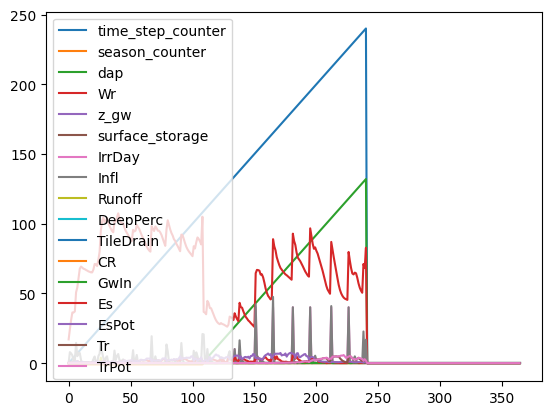

In [9]:
hist_run.water_flux.plot()

<Axes: >

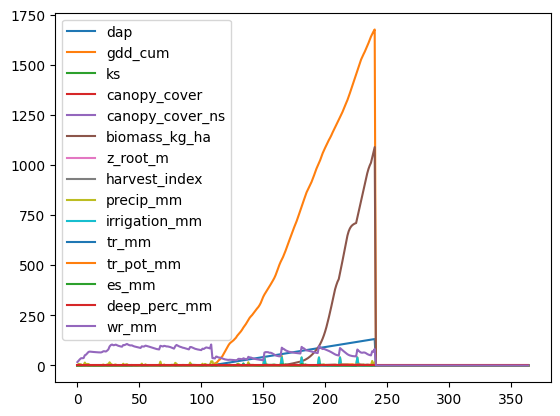

In [10]:
hist_run.daily_stress.plot()

In [10]:
hist_run.daily_stress

,dap,gdd_cum,ks,canopy_cover,canopy_cover_ns,biomass_kg_ha,z_root_m,harvest_index,precip_mm,irrigation_mm,tr_mm,tr_pot_mm,es_mm,deep_perc_mm,wr_mm
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.014871,0.0,0.0,0.0,0.014871,0.0,17.00
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,7.829189,0.0,0.0,0.0,0.541376,0.0,24.29
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.934652,0.0,0.0,0.0,0.297348,0.0,30.92
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.500510,0.0,0.0,0.0,0.130799,0.0,36.30
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.762910,0.0,0.0,0.0,0.732111,0.0,36.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00
361,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00
362,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00
363,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00


In [11]:
hist_run.final_results

,Season,crop Type,Harvest Date (YYYY/MM/DD),Harvest Date (Step),Dry yield (tonne/ha),Fresh yield (tonne/ha),Yield potential (tonne/ha),Seasonal irrigation (mm)
0,0,Maize,2025-08-30,240,1.349655,1.499616,2.661108,250.0


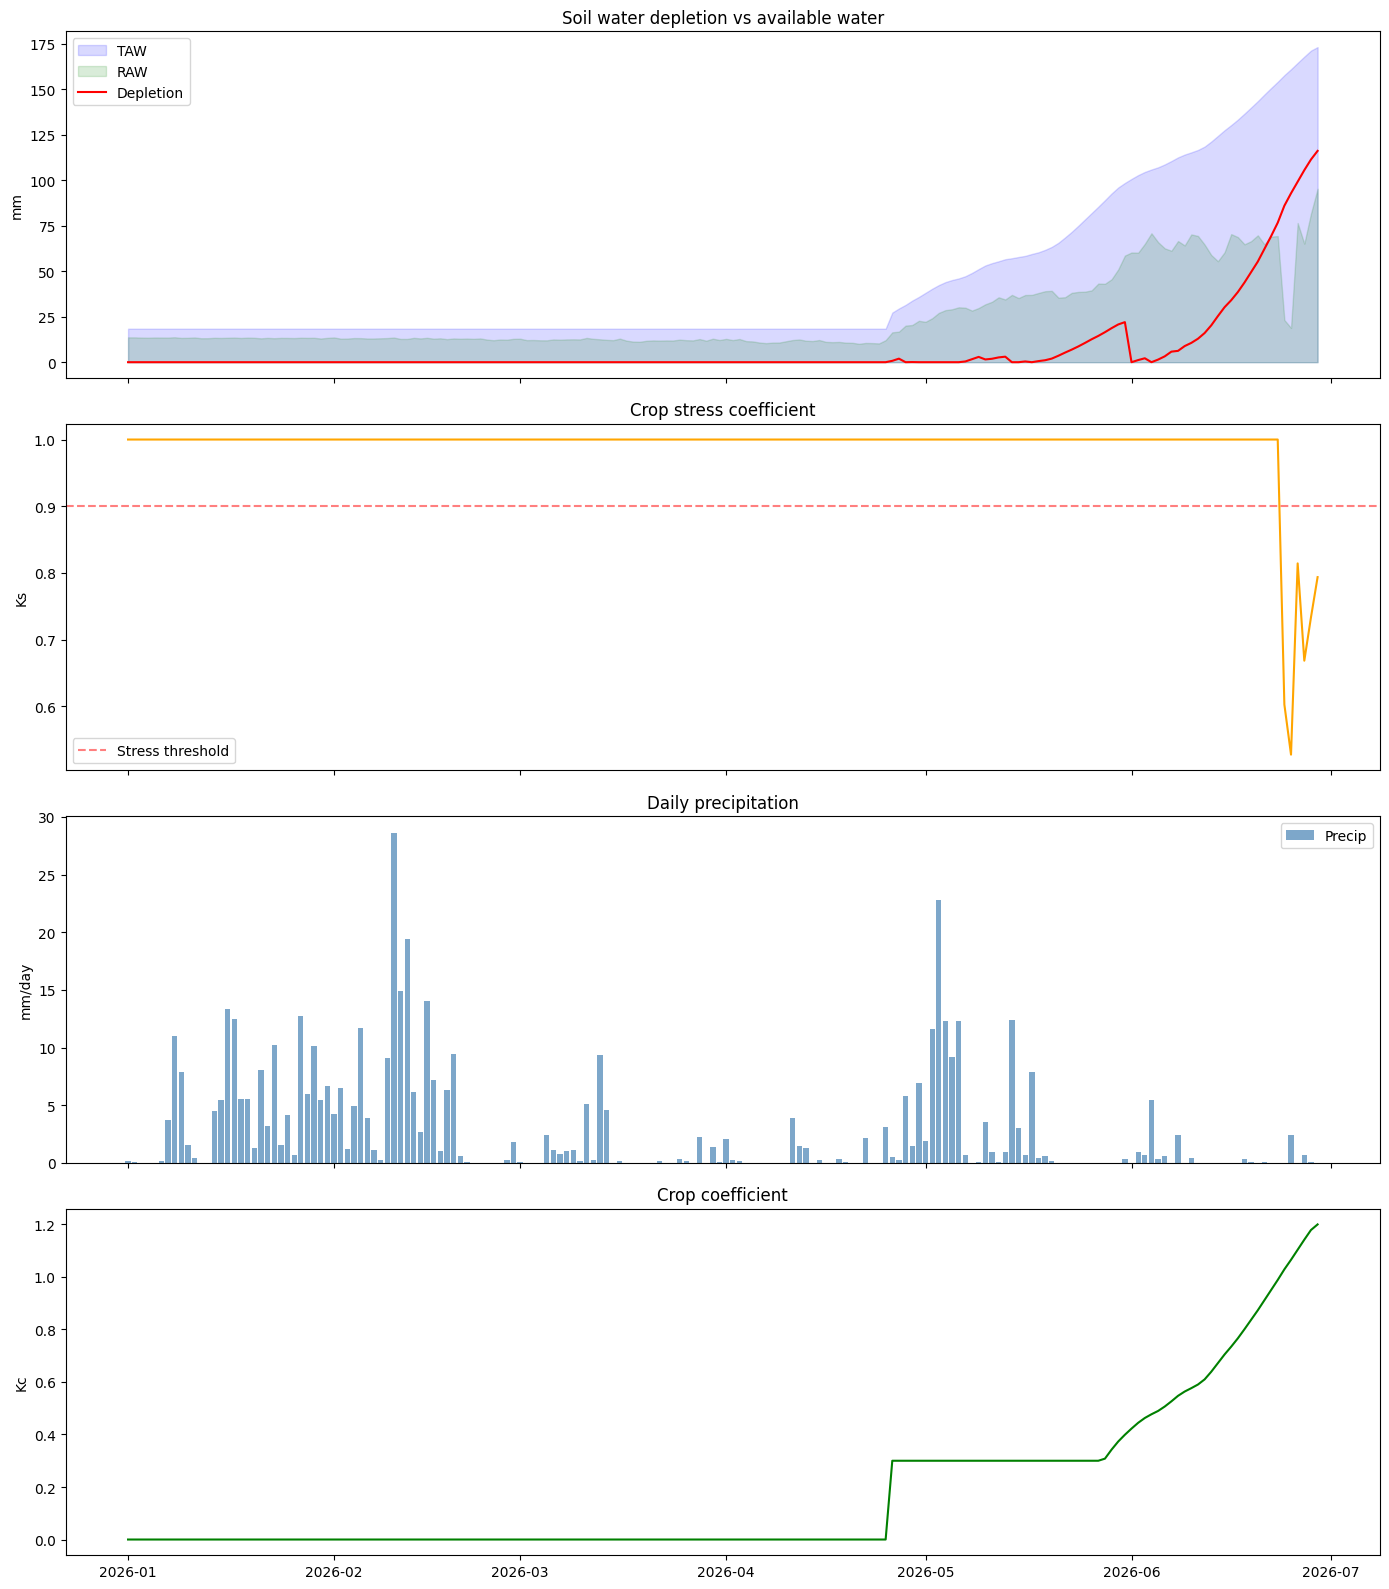

In [21]:
# Plot historical simulation
df_hist = states_to_dataframe(states)

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

axes[0].fill_between(df_hist.index, 0, df_hist["taw"], alpha=0.15, color="blue", label="TAW")
axes[0].fill_between(df_hist.index, 0, df_hist["raw"], alpha=0.15, color="green", label="RAW")
axes[0].plot(df_hist.index, df_hist["depletion"], color="red", lw=1.5, label="Depletion")
axes[0].set_ylabel("mm")
axes[0].set_title("Soil water depletion vs available water")
axes[0].legend()

axes[1].plot(df_hist.index, df_hist["stress_coeff"], color="orange", lw=1.5)
axes[1].axhline(0.9, color="red", ls="--", alpha=0.5, label="Stress threshold")
axes[1].set_ylabel("Ks")
axes[1].set_title("Crop stress coefficient")
axes[1].legend()

axes[2].bar(df_hist.index, df_hist["precip"], color="steelblue", alpha=0.7, label="Precip")
axes[2].set_ylabel("mm/day")
axes[2].set_title("Daily precipitation")
axes[2].legend()

axes[3].plot(df_hist.index, df_hist["kc"], color="green", lw=1.5)
axes[3].set_ylabel("Kc")
axes[3].set_title("Crop coefficient")

plt.tight_layout()
plt.show()

---
## Block 5a — Operational forecast pipeline

- **ERA5-Land** (Jan 1 → ~5 days ago): reanalysis, cached
- **AROME** rolling analysis (gap → today): near real-time, from France-wide cache
- **AROME** (0-48h, deterministic, 1.3 km): deterministic, high-res
- **IFS ENS** (0-15d, 51 members, 0.25°): ensemble, probabilistic
- Blended: days 0-2 from AROME, days 3+ from IFS ENS

⚠️ For historical dates (TODAY in the past), we skip live forecast fetching
and use ERA5-Land as a stand-in to demonstrate the pipeline.

In [12]:
# Determine ERA5-Land coverage and gap to fill
from datetime import timedelta
import pandas as pd

era5_last = pd.Timestamp(era5_daily.valid_time.values[-1]).date()
print(f"ERA5-Land last day: {era5_last}")
print(f"Today:              {TODAY}")
print(f"Gap to fill:        {(TODAY - era5_last).days - 1} days")

ERA5-Land last day: 2026-06-23
Today:              2026-06-29
Gap to fill:        5 days


In [13]:
# --- Step 1: ERA5-Land historical (already done in Block 2) ---
era5_forcing = forcing.slice(SIMULATION_START, era5_last)
print(f"ERA5-Land forcing: {era5_forcing.n_days} days")

ERA5-Land forcing: 174 days


In [14]:
# --- Step 2: AROME rolling analysis fills the gap ---
from irrigator.forecasts.short_term import standardize_forecast_to_era5_format
from irrigator.forecasts.arome_processing import load_arome_daily_cache

gap_start = era5_last + timedelta(days=1)
gap_end = TODAY - timedelta(days=1)  # yesterday

# For HISTORICAL testing (TODAY in the past), use ERA5-Land as gap stand-in:
# if gap_start <= gap_end:
#     gap_forcing = forcing.slice(gap_start, gap_end)
#     print(f"Gap filled: {gap_forcing.n_days} days ({gap_start} → {gap_end})")
# else:
#     gap_forcing = None
#     print("No gap to fill")

# For LIVE operation, use the AROME France-wide daily cache:
from irrigator.atmospheric.forcing import extract_parcel_forcing
arome_cache = load_arome_daily_cache(gap_start, gap_end)
gap_forcing = extract_parcel_forcing(arome_cache, parcel, terrain)

17:51:15 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 5 days from ERA5-Land at grid cell (0, 45)
17:51:15 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
17:51:15 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 5 days, T=[22.3, 42.9]°C, total precip=3 mm, mean Rs=27.6 MJ/m²/day


In [15]:
import numpy as np 

# --- Step 3: AROME 48h deterministic forecast (today → +2d) ---
# For LIVE:
arome_today = load_arome_daily_cache(TODAY, TODAY + timedelta(days=1), mode = "forecast")
arome_forcing_48h = extract_parcel_forcing(arome_today, parcel, terrain)
arome_forcing_48h.dates = arome_forcing_48h.dates - np.timedelta64(1, "D")

# # For HISTORICAL testing: use ERA5-Land as stand-in
# arome_forcing_48h = forcing.slice(TODAY, TODAY + timedelta(days=1))
# print(f"AROME forecast: {arome_forcing_48h.n_days} days")

17:51:16 [arome] WARNING: 1 missing days: [datetime.date(2026, 6, 30)]
17:51:16 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 2 days from ERA5-Land at grid cell (0, 45)
17:51:16 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
17:51:16 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 2 days, T=[18.7, 32.0]°C, total precip=0 mm, mean Rs=25.7 MJ/m²/day


In [16]:
# --- Step 4: Stitch everything → run historical simulation ---
# ERA5-Land + gap + AROME today
full_forcing = era5_forcing
if gap_forcing:
    full_forcing = full_forcing.concat(gap_forcing)
full_forcing = full_forcing.concat(arome_forcing_48h)

print(f"Full forcing: {full_forcing.n_days} days ({SIMULATION_START} → ...)")

# Run simulation up to current state
states = run_simulation(
    forcing=full_forcing.slice(SIMULATION_START, TODAY),
    parcel=parcel,
    terrain=terrain,
    soil=soil,
    crop_params=crop_params,
)
current_state = states[-1]
print(f"Current state: Dr={current_state.depletion:.0f} mm, Ks={current_state.stress_coeff:.3f}")

18:11:27 [irrigator.water_balance.bucket_model] INFO: Starting simulation: 180 days, parcel 24_bergerac_001, planting 2026-04-20
18:11:27 [irrigator.water_balance.bucket_model] INFO: Simulation complete: 180 days, GDD=706, precip=474 mm, ETc=173 mm, irrigation=110 mm, drainage=386 mm, stress days=6


Full forcing: 181 days (2026-01-01 → ...)
Current state: Dr=116 mm, Ks=0.794


In [17]:
from irrigator.forecasts.short_term import run_forward_balance
# --- Step 5: AROME deterministic forward balance (days 0-2) ---
arome_states = run_forward_balance(
    current_state,
    arome_forcing_48h,
    parcel,
    terrain,
    soil,
    crop_params,
)
print("AROME deterministic (days 0-2):")
for s in arome_states:
    print(f"  {s.date}: Ks={s.stress_coeff:.3f}, Dr={s.depletion:.0f} mm")

AROME deterministic (days 0-2):
  2026-06-29: Ks=0.733, Dr=120 mm
  2026-06-30: Ks=0.574, Dr=125 mm


In [18]:
# --- Step 6: IFS ENS ensemble forward balance (days 0-15) ---
from irrigator.forecasts.short_term import DailyForcing
from irrigator.atmospheric.forcing import extract_parcel_forcing

if TODAY >= date.today() - timedelta(days=14):
    # LIVE: load from IFS ENS France-wide daily cache
    from irrigator.ingestion.ifs_ens_client import load_ifs_daily
    ifs_daily = load_ifs_daily(processed_dir=PROCESSED_DIR)

    member_forcings = {}
    for m in ifs_daily.number.values:
        member_ds = ifs_daily.sel(number=m)
        member_forcings[int(m)] = extract_parcel_forcing(member_ds, parcel, terrain)
    # print(f"IFS ENS: {len(member_forcings)} members, {member_forcings[0].n_days} days")

else:
    # HISTORICAL testing: synthetic ensemble from ERA5-Land
    import numpy as np

    rng = np.random.default_rng(42)
    n_members = 20
    forecast_end = TODAY + timedelta(days=10)
    pseudo_forcing = forcing.slice(TODAY + timedelta(days=1), forecast_end)

    member_forcings = {}
    for m in range(n_members):
        member_forcings[m] = DailyForcing(
            dates=pseudo_forcing.dates.copy(),
            t_min=pseudo_forcing.t_min + rng.normal(0, 1.0, pseudo_forcing.n_days),
            t_max=pseudo_forcing.t_max + rng.normal(0, 1.0, pseudo_forcing.n_days),
            t_mean=pseudo_forcing.t_mean + rng.normal(0, 0.8, pseudo_forcing.n_days),
            dewpoint=pseudo_forcing.dewpoint + rng.normal(0, 0.5, pseudo_forcing.n_days),
            wind_speed_2m=np.clip(
                pseudo_forcing.wind_speed_2m + rng.normal(0, 0.3, pseudo_forcing.n_days), 0, None
            ),
            pressure_kpa=pseudo_forcing.pressure_kpa.copy(),
            rs_mj=np.clip(pseudo_forcing.rs_mj + rng.normal(0, 2, pseudo_forcing.n_days), 0, None),
            precip_mm=np.clip(
                pseudo_forcing.precip_mm * rng.lognormal(0, 0.5, pseudo_forcing.n_days), 0, None
            ),
        )
    print(f"Synthetic ensemble: {n_members} members, {pseudo_forcing.n_days} days")

18:12:26 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
18:12:26 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
18:12:26 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 16 days, T=[17.5, 37.5]°C, total precip=0 mm, mean Rs=27.2 MJ/m²/day
18:12:26 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
18:12:26 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
18:12:26 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 16 days, T=[17.5, 37.2]°C, total precip=1 mm, mean Rs=26.8 MJ/m²/day
18:12:26 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
18:12:26 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
18:12:26 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forc

In [19]:
# --- Step 7: Blended ensemble stress report ---
# AROME overrides days 0-2, IFS ENS provides ensemble spread for days 3+
from irrigator.forecasts.short_term import run_ensemble_forward_balance

stress_report = run_ensemble_forward_balance(
    current_state=current_state,
    member_forcings=member_forcings,
    parcel=parcel,
    terrain=terrain,
    soil=soil,
    crop_params=crop_params,
    arome_states=arome_states,
    arome_days=2,  # AROME covers 48h = 2 days
)

18:12:27 [irrigator.forecasts.short_term] INFO: Ensemble stress report: 16 days (2 AROME + 14 IFS ENS), 50 members, stress_expected=True, first_stress_day=0


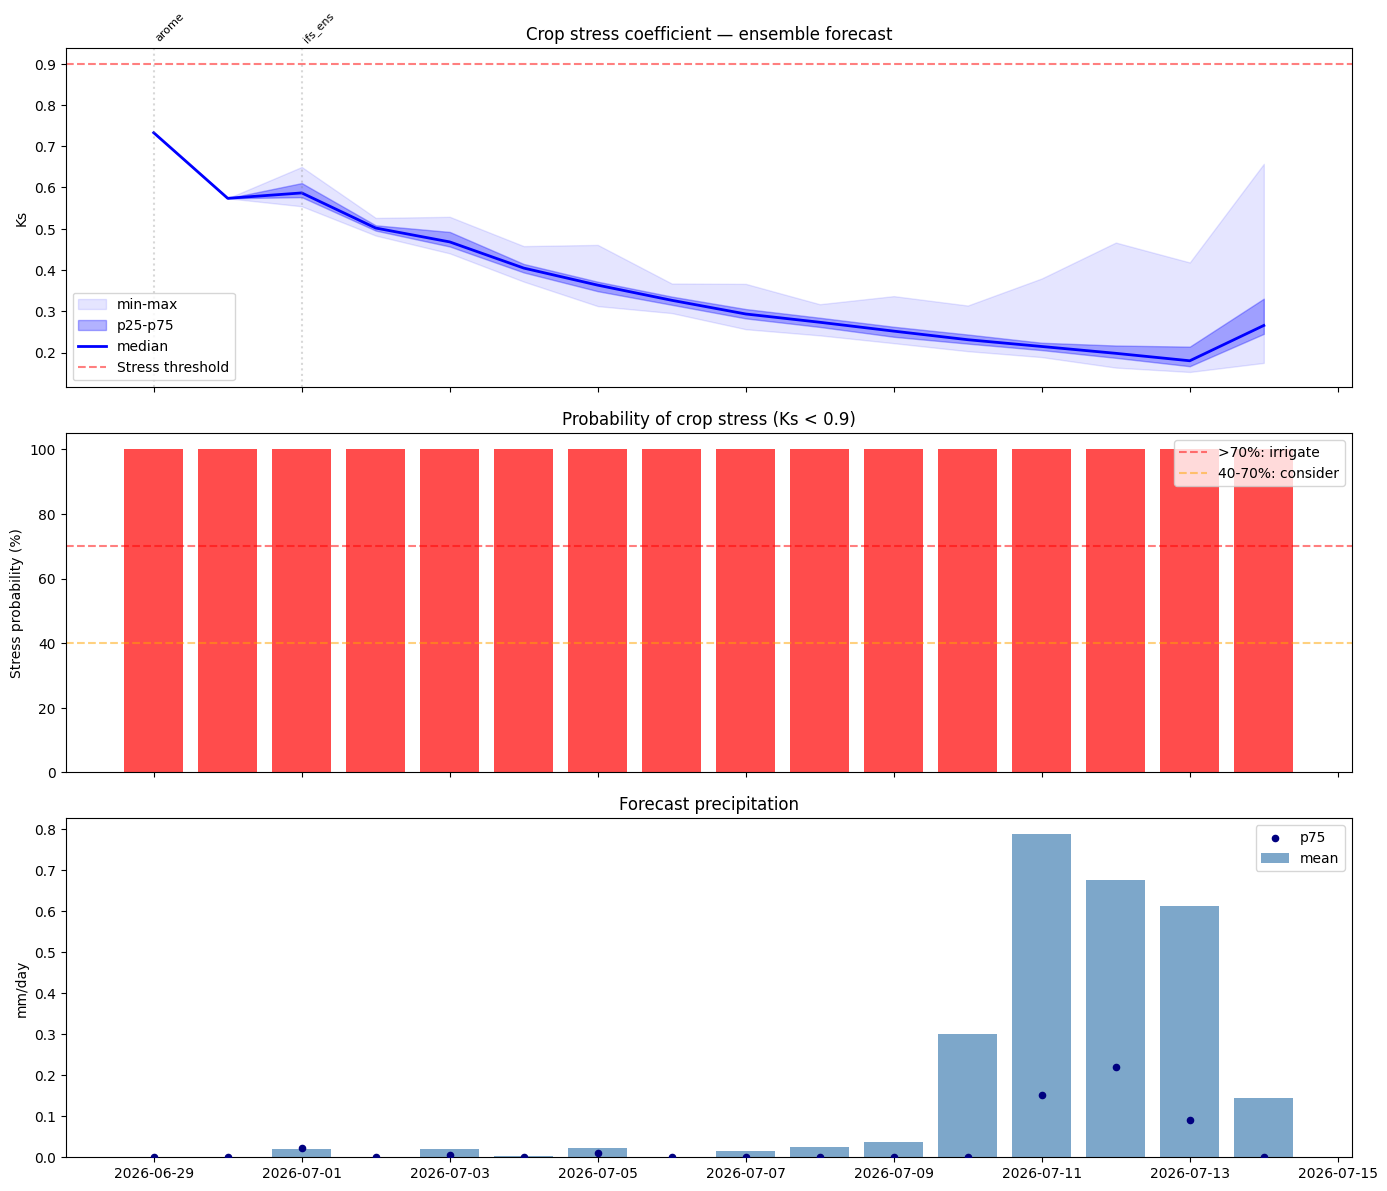

In [20]:
# --- Plot ensemble forecast ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

dates = [d.date for d in stress_report.daily_stats]
sources = [d.source for d in stress_report.daily_stats]

# Ks with ensemble spread
ax = axes[0]
ks_med = [d.ks_median for d in stress_report.daily_stats]
ks_p25 = [d.ks_p25 for d in stress_report.daily_stats]
ks_p75 = [d.ks_p75 for d in stress_report.daily_stats]
ks_min = [d.ks_min for d in stress_report.daily_stats]
ks_max = [d.ks_max for d in stress_report.daily_stats]

ax.fill_between(dates, ks_min, ks_max, alpha=0.1, color="blue", label="min-max")
ax.fill_between(dates, ks_p25, ks_p75, alpha=0.3, color="blue", label="p25-p75")
ax.plot(dates, ks_med, "b-", lw=2, label="median")
ax.axhline(0.9, color="red", ls="--", alpha=0.5, label="Stress threshold")

for i, (d, src) in enumerate(zip(dates, sources)):
    if i == 0 or sources[i] != sources[i-1]:
        ax.axvline(d, color="gray", ls=":", alpha=0.3)
        ax.text(d, 1.02, src, fontsize=8, rotation=45, transform=ax.get_xaxis_transform())

ax.set_ylabel("Ks")
ax.set_title("Crop stress coefficient — ensemble forecast")
ax.legend(loc="lower left")

# Stress probability
ax = axes[1]
stress_prob = [d.n_members_stressed / max(d.n_members_total, 1) for d in stress_report.daily_stats]
colors = ["red" if p > 0.7 else "orange" if p > 0.4 else "green" for p in stress_prob]
ax.bar(dates, [p * 100 for p in stress_prob], color=colors, alpha=0.7)
ax.axhline(70, color="red", ls="--", alpha=0.5, label=">70%: irrigate")
ax.axhline(40, color="orange", ls="--", alpha=0.5, label="40-70%: consider")
ax.set_ylabel("Stress probability (%)")
ax.set_title("Probability of crop stress (Ks < 0.9)")
ax.legend()

# Precipitation
ax = axes[2]
precip_mean = [d.precip_mean for d in stress_report.daily_stats]
precip_p75 = [d.precip_p75 for d in stress_report.daily_stats]
ax.bar(dates, precip_mean, color="steelblue", alpha=0.7, label="mean")
ax.scatter(dates, precip_p75, color="navy", s=20, zorder=5, label="p75")
ax.set_ylabel("mm/day")
ax.set_title("Forecast precipitation")
ax.legend()

plt.tight_layout()
plt.show()

---
## Block 5b — Seasonal Outlook (SEAS5, optional)

PCA analog matching → daily disaggregation → ensemble water balance.
Set `RUN_SEAS5 = True` at the top to enable.

In [ ]:
outlook = None

if RUN_SEAS5:
    from irrigator.ingestion.cds_client import fetch_seas5, open_seas5
    from irrigator.forecasts.seas5_processor import (
        build_era5_monthly_climatology,
        correct_seas5_monthly,
    )
    from irrigator.forecasts.disaggregation import generate_seasonal_scenarios
    from irrigator.decision.seasonal_outlook import compute_seasonal_outlook

    init_year = TODAY.year
    init_month = TODAY.month

    # Fetch + bias correct SEAS5
    fetch_seas5(year=init_year, month=init_month, raw_dir=RAW_DIR)
    seas5_anom = open_seas5(raw_dir=RAW_DIR, year=init_year, month=init_month)
    era5_clim = build_era5_monthly_climatology(
        start_year=1993, end_year=2016, processed_dir=PROCESSED_DIR,
    )
    seas5_corrected = correct_seas5_monthly(seas5_anom, era5_clim, init_month=init_month)

    # Analog disaggregation (PCA + Mahalanobis + spatial voting)
    scenarios = generate_seasonal_scenarios(
        cfg=cfg,
        era5_daily=era5_daily,
        seas5_corrected=seas5_corrected,
        init_month=init_month,
        n_leads=4,
    )

    # Run water balance under each scenario
    outlook = compute_seasonal_outlook(
        scenarios=scenarios,
        parcel=parcel,
        terrain=terrain,
        soil=soil,
        crop_params=crop_params,
    )

    print(f"\nSeasonal outlook ({outlook.n_members} members):")
    print(f"  Irrigation needed: {outlook.total_irrigation_p25:.0f}–{outlook.total_irrigation_p75:.0f} mm (p25–p75)")
    print(f"  Median: {outlook.total_irrigation_median:.0f} mm")
    print(f"  Stress days: median {outlook.stress_days_median:.0f}")
    print(f"  {outlook.season_description}")
else:
    print("SEAS5 seasonal outlook skipped (set RUN_SEAS5=True to enable)")

---
## Block 6 — Irrigation Decision

Combines current soil state + ensemble forecast → actionable recommendation.

In [19]:
from irrigator.decision.rules import compute_recommendation, DecisionParams
from irrigator.decision.output import build_parcel_report, save_report, format_sms

params = DecisionParams.from_config(
    model_params_path=MODEL_PARAMS_PATH,
    parcel=parcel,
)

# Ensemble-aware recommendation (uses stress_report from Block 5a)
advice = compute_recommendation(
    current_state=current_state,
    stress_report=stress_report,
    crop_params=crop_params,
    params=params,
    last_irrigation_date=LAST_IRRIGATION,
)

print(f"\n{'='*60}")
print(f"IRRIGATION RECOMMENDATION for {parcel.name}")
print(f"{'='*60}")
print(f"  Action:     {"Irrigate" if advice.irrigate else "No need to irrigate"}")
print(f"  Amount:     {advice.dose_mm:.0f}")
print(f"  Confidence: {advice.confidence}")
print(f"  Reason:     {advice.reason}")
print(f"{'='*60}")


IRRIGATION RECOMMENDATION for Parcelle Les Graves
  Action:     Irrigate
  Amount:     40
  Confidence: high
  Reason:     100% of ensemble members show stress. Depletion 126/173 mm. Forecast rain: 1 mm. Recommend 40 mm on 2026-06-29 (CRITICAL: flowering window)


In [49]:
# Build and save JSON report
report = build_parcel_report(
    parcel_id=parcel.id,
    today=TODAY,
    advice=advice,
    outlook=outlook,
)

import json
print(json.dumps(report, indent=2, default=str))

NameError: name 'outlook' is not defined

In [ ]:
# Save to disk
save_report(report, Path("output/"))

# SMS format
print(f"\nSMS: {format_sms(advice)}")

---
## Summary: data flow

```
ERA5-Land France-wide cache ──[Block 2: extract + downscale]──→ DailyForcing (parcel)
                                                                       │
                                                      [Blocks 3+4: simulation]──→ current_state
                                                                                        │
AROME France-wide cache ──[extract + downscale]──→ DailyForcing (parcel)                │
                                                         │                              │
IFS ENS download ──[process daily]──[extract]──→ 51× DailyForcing (parcel)              │
                                                         │                              │
                                              [Block 5a: ensemble forward balance]──────┤
                                                                                        │
SEAS5 ──[bias correct]──[PCA analog]──[extract]──→ N× DailyForcing                     │
                                                         │                              │
                                              [Block 5b: seasonal water balance]────────┤
                                                                                        │
                                              [Block 6: decision rules]─────→ IrrigationAdvice
```

All gridded data sources (ERA5-Land, AROME, IFS ENS, SEAS5 analogs) are France-wide.
Parcel extraction happens once through `extract_parcel_forcing()` — one function,
one set of corrections (lapse rate, radiation, wind), for all sources.